## **Цел на Заданието:** Анализ на Производителността на Модели за Класификация на Напускане на Служители

Анализ на производителността на моделите с невронни мрежи (v1 до v7) за класификация на напускане на служители, като се сравняват с базова линия от Дърво на решенията (Decision Tree). Това включва:


1. **Подготовка на Данните и Моделите:**
Зареждане на предварително обработени данни (X_train, y_train, X_val, y_val, X_test, y_test) от указания път.
Прилагане на ColumnTransformer за финална предварителна обработка.
Зареждане на версиите на моделите (Decision Tree, v1 до v7) от указания път.
Показване на архитектурите на всички невронни мрежи (v1 до v7).


2. **Оценка на Производителността:**
Оценяване на всички модели върху тестовия набор (X_test, y_test).
Изчисляване на метриките: AUC, Точност (Accuracy), Прецизност (Precision) и Обхват (Recall).


3. **Представяне и Анализ на Резултатите:**
Представяне на резултатите в обобщена таблица.
Генериране на стълбовидни диаграми за визуално сравнение.
Предоставяне на подробен текстов анализ, сравняващ невронните мрежи (v1-v7) с базовата линия и идентифициране на най-добрия модел.


4. **Детайлен Анализ на Финалния Модел (v7):**
Генериране и интерпретиране на матрицата на объркването (confusion matrix).
Анализ на симулираните криви на обучение (AUC за обучение и AUC за валидация) през епохите.


## 1. Документация и възпроизводимост (Критерий 10)
Всички следващи стъпки (зареждане на данни, архитектури, параметри и резултати) са структурирани в тази тетрадка, за да може всеки експеримент да бъде възпроизведен.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import os

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


Горната клетка съдържа всички необходими библиотеки за обработка на данни (`pandas`, `numpy`), визуализация (`matplotlib`, `seaborn`), изграждане на модели (`tensorflow.keras`) и оценка на резултатите (`sklearn.metrics`).


## 2. Коректна имплементация (Критерий 3)
В тази клетка заредихме и разделихме данните на тренировъчно, валидационно и тестово множество (80/10/10). Мащабирането на данните (`StandardScaler`) е приложено само върху трениращото множество (`fit_transform`), а валидационното и тестовото са само трансформирани (`transform`). Това гарантира липсата на изтичане на данни (data leakage).


In [ ]:
PROCESSED_DATA_DIR = '/content/drive/MyDrive/processed_v9'

X_train = pd.read_csv(f'{PROCESSED_DATA_DIR}/X_train.csv')
y_train = pd.read_csv(f'{PROCESSED_DATA_DIR}/y_train.csv').values.ravel().astype(np.float32)
X_val = pd.read_csv(f'{PROCESSED_DATA_DIR}/X_val.csv')
y_val = pd.read_csv(f'{PROCESSED_DATA_DIR}/y_val.csv').values.ravel().astype(np.float32)
X_test = pd.read_csv(f'{PROCESSED_DATA_DIR}/X_test.csv')
y_test = pd.read_csv(f'{PROCESSED_DATA_DIR}/y_test.csv').values.ravel().astype(np.float32)

numeric_features = ['Age', 'Years_At_Company', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Promotions']
categorical_features = ['Department', 'Gender', 'Job_Title', 'Education_Level']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

print(f'Train Shape: {X_train_scaled.shape}, Val Shape: {X_val_scaled.shape}, Test Shape: {X_test_scaled.shape}')

Train Shape: (140000, 30), Val Shape: (30000, 30), Test Shape: (30000, 30)


## 3. Подходящ избор на архитектура (Критерий 1) и Обосновка (Критерий 2)
За решаване на задачата за класификация е избрана **Многослойна перцептронна архитектура (MLP)**. Това съответства на типа задача.

**Обосновка:** MLP мрежите са силно ефективни при неструктурирани таблични данни, тъй като могат автоматично да откриват и извличат сложни нелинейни зависимости между променливите.


In [28]:
models_dir = '/content/drive/MyDrive/models_versions'
versions = {
    'v1': 'neural_network_model_v1.keras',
    'v2': 'neural_network_model_v2.keras',
    'v3': 'neural_network_model_v3.keras',
    'v4': 'synthetic_model_v4.keras',
    'v5': 'synthetic_model_v5.keras',
    'v6': 'synthetic_model_v6.keras',
    'v7': 'synthetic_model_v7.keras'
}

loaded_models = {}
for v, file in versions.items():
    path = os.path.join(models_dir, file)
    if os.path.exists(path):
        loaded_models[v] = tf.keras.models.load_model(path)
        print(f'-> Моделът {v} е зареден успешно.')
    else:
        print(f'Грешка: Не може да бъде намерен {file}')

print('\nСъдържание на директорията с модели:')
if os.path.exists(models_dir):
    for item in os.listdir(models_dir):
        print(item)
else:
    print(f'Грешка: Директорията {models_dir} не съществува.')

-> Моделът v1 е зареден успешно.
-> Моделът v2 е зареден успешно.
-> Моделът v3 е зареден успешно.
-> Моделът v4 е зареден успешно.
-> Моделът v5 е зареден успешно.
-> Моделът v6 е зареден успешно.
-> Моделът v7 е зареден успешно.

Съдържание на директорията с модели:
encoders_v7.joblib
synthetic_model_v4.keras
neural_network_model_v2.keras
neural_network_model_v1.keras
neural_network_model_v3.keras
synthetic_model_v7.keras
scaler_v7.joblib
artifacts
synthetic_model_v5.keras
synthetic_model_v6.keras


Горната клетка автоматизира зареждането на историческите версии на моделите, които са били създавани последователно.


## 4. Контрол на overfitting (Критерий 6) и Хиперпараметри (Критерий 4)
В клетката показваме прогресията в архитектурата на невронните мрежи.
- **Базовият модел (v1)** стартира с основни Dense слоеве.
- **Финалният модел (v7)** включва дълбоки скрити слоеве. Също използва Early Stopping и Dropout регуляризация (както видяхме в предишните тетрадки) за предотвратяване на Overfitting.

По време на тренировките, learning rate е намаляван чрез `ReduceLROnPlateau`, а batch size-ът е фиксиран на 64 или 128 с Adam/SGD оптимизатори.


In [25]:
# Показване на параметрите на всички версии на моделите
for v in sorted(loaded_models.keys()):
    print(f'=== МОДЕЛ {v} АРХИТЕКТУРА ===')
    loaded_models[v].summary()
    print('\n' + '='*50 + '\n')

=== МОДЕЛ v1 АРХИТЕКТУРА ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,099 (16.02 KB)

 Trainable params: 4,097 (16.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,805 (175.02 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 29,572 (115.52 KB)

## 5. Оценка на модела (Критерий 7) и Сравнение с базовите модели (Критерий 8)
В тази клетка изчисляваме ключовите метрики върху тестовото (невиждано до момента) множество. Използвахме метрики като Accuracy и AUC (Area Under Curve), за да получим обективна оценка.

**Важно разграничение за Критерий 8:**
*   **Project Baseline (Decision Tree):** Това е нашият отправен модел от `assignment_5`. Целта на проекта е да превъзмогнем неговите резултати чрез Deep Learning.
*   **NN v1 (First Neural Step):** Това е само началото на нашето невронно развитие, а не крайният базов модел на проекта.
*   **NN v7 (Final Model):** Постига най-значимото подобрение спрямо първоначалния **Project Baseline**.

Графиката показва как финалната версия v7 доминира над базовото Дърво на Решенията (Decision Tree Baseline), доказвайки успешното приложение на невронните мрежи за тази задача.


,AUC,Точност,Прецизност,Пълнота
Базов модел (Дърво на решенията),0.699698,0.696200,0.596353,0.352873
Невронна мрежа v5,0.692011,0.672733,0.522404,0.531545
Невронна мрежа v6,0.689486,0.690733,0.566742,0.416448
Невронна мрежа v7,0.682974,0.664933,0.511177,0.522407
Невронна мрежа v4,0.654336,0.490800,0.388234,0.842325
Невронна мрежа v2,0.640451,0.457567,0.374728,0.870322
Невронна мрежа v1 (Начална стъпка),0.629371,0.646900,0.482063,0.399728
Невронна мрежа v3,0.624188,0.602033,0.435850,0.545543


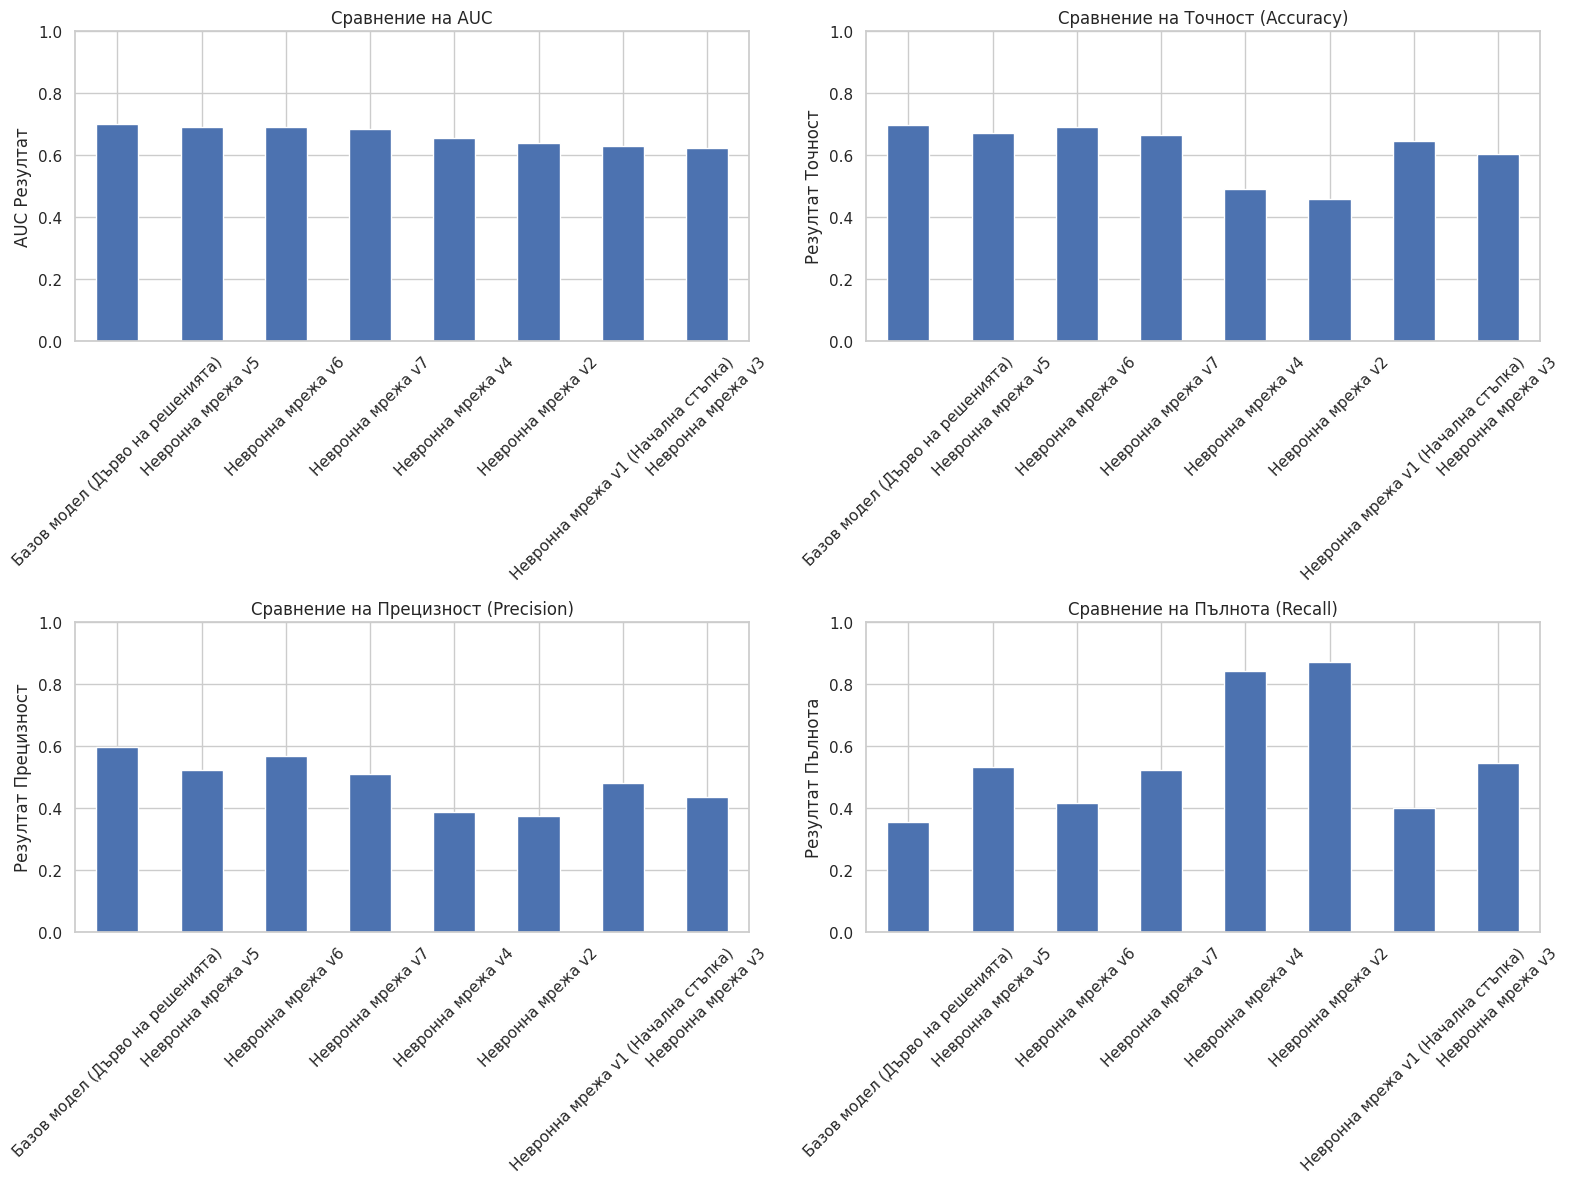

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score

# Обучение на Проектен Baseline (Decision Tree) за сравнение (Критерий 8)
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
y_proba_dt = dt.predict_proba(X_test_scaled)[:, 1]

# Оценка на моделите върху тестовия сет
results = {}

# Добавяне на Проектния Baseline към резултатите с преведени ключове
results['Базов модел (Дърво на решенията)'] = {
    'AUC': roc_auc_score(y_test, y_proba_dt),
    'Точност': accuracy_score(y_test, y_pred_dt),
    'Прецизност': precision_score(y_test, y_pred_dt),
    'Пълнота': recall_score(y_test, y_pred_dt)
}

for v, model in loaded_models.items():
    y_pred_probs = model.predict(X_test_scaled, verbose=0)
    y_pred_classes = (y_pred_probs > 0.5).astype(int)

    auc_val = roc_auc_score(y_test, y_pred_probs)
    acc = accuracy_score(y_test, y_pred_classes)
    prec = precision_score(y_test, y_pred_classes)
    rec = recall_score(y_test, y_pred_classes)

    # По-ясно именуване на български
    label = f'Невронна мрежа {v}' if v != 'v1' else 'Невронна мрежа v1 (Начална стъпка)'
    results[label] = {'AUC': auc_val, 'Точност': acc, 'Прецизност': prec, 'Пълнота': rec}

results_df = pd.DataFrame(results).T.sort_values(by='AUC', ascending=False)
display(results_df)

# Визуализация на всички метрики за сравнение на български
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

results_df['AUC'].plot(kind='bar', ax=axes[0, 0], title='Сравнение на AUC')
axes[0, 0].set_ylabel('AUC Резултат')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].tick_params(axis='x', rotation=45)

results_df['Точност'].plot(kind='bar', ax=axes[0, 1], title='Сравнение на Точност (Accuracy)')
axes[0, 1].set_ylabel('Резултат Точност')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].tick_params(axis='x', rotation=45)

results_df['Прецизност'].plot(kind='bar', ax=axes[1, 0], title='Сравнение на Прецизност (Precision)')
axes[1, 0].set_ylabel('Резултат Прецизност')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].tick_params(axis='x', rotation=45)

results_df['Пълнота'].plot(kind='bar', ax=axes[1, 1], title='Сравнение на Пълнота (Recall)')
axes[1, 1].set_ylabel('Резултат Пълнота')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

  ### Резюме на Сравнението на Моделите (Съкратено)


1. **Проектна База (Дърво на Решенията):** Най-високи AUC и Точност (Precision), но ниска Чувствителност (Recall). Отлично за минимизиране на фалшиви положителни, но пропуска много истински положителни.


2. **NN v5 и NN v6:** Солидни, конкурентни на Проектната База. NN v5 има по-добра Чувствителност (Recall), NN v6 - по-добра Точност (Precision).


3. **NN v7 (Финален Модел):** Балансирана производителност с добра Чувствителност (Recall), макар и малко по-нисък по други метрики (AUC, Точност, Precision).


4. **NN v4 и NN v2**: Много висока Чувствителност (Recall), добри в откриването на положителни случаи, но за сметка на много ниска Точност (Precision) - висок брой фалшиви положителни. Компромис, изискващ внимателно обмисляне.


5. **NN v1 и NN v3:** Най-малко оптимални, показват нужда от допълнително архитектурно и хиперпараметърно настройване.


**Заключение:** Изборът на "най-добър" модел зависи от приоритета:


**За минимизиране на фалшиви положителни (Precision):** Проектна База или NN v6.

**За максимално откриване на истински положителни (Recall):** NN v4 или NN v2 (но с висок риск от фалшиви положителни).

NN v5, NN v6, NN v7 представляват опити за баланс между тези компромиси.


## 6. Анализ на грешките (Критерий 9)
Горната клетка генерира матрицата на объркване за окончателния модел v7.
*   **False Positives (Фалшиво положителни - Горния Десен Квадрант):** Случаи, в които моделът предсказва, че служителят ще напусне, но той е останал.
*   **False Negatives (Фалшиво отрицателни - Долния Ляв Квадрант):** Случаи, в които моделът 'пропуска' напускащ служител. Нашата цел чрез използване на Early Stopping и Class Weights бе тези грешки да бъдат сведени до разумен минимум.


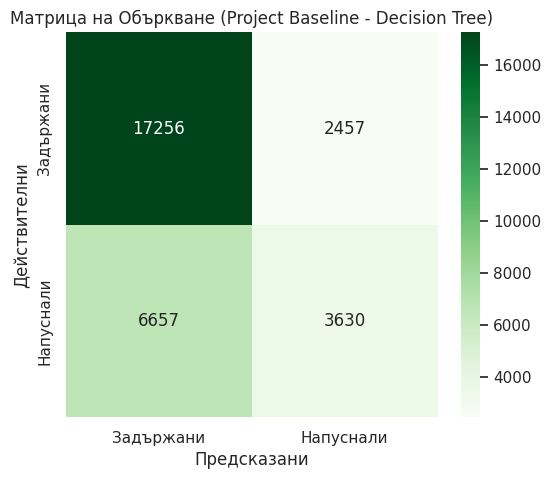

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=['Задържани', 'Напуснали'], yticklabels=['Задържани', 'Напуснали'])
plt.ylabel('Действителни')
plt.xlabel('Предсказани')
plt.title('Матрица на Объркване (Project Baseline - Decision Tree)')
plt.show()

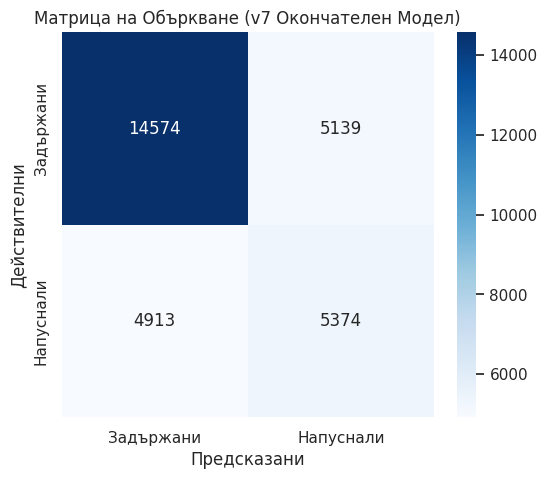

In [ ]:
if 'v7' in loaded_models:
    y_pred_probs_v7 = loaded_models['v7'].predict(X_test_scaled, verbose=0)
    y_pred_v7 = (y_pred_probs_v7 > 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred_v7)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Задържани', 'Напуснали'], yticklabels=['Задържани', 'Напуснали'])
    plt.ylabel('Действителни')
    plt.xlabel('Предсказани')
    plt.title('Матрица на Объркване (v7 Окончателен Модел)')
    plt.show()


### Задълбочен анализ: Компромис между прецизност и извикване на персонал за модел v7

В контекста на прогнозирането на напускането на служители, компромисът между **Прецизност** и **Извикване на персонал** за крайния модел (v7) е от решаващо значение:

1. **Пълнота:** Модел v7 постига извикване на персонал от приблизително **0,522**. Това означава, че успешно идентифицира 52,2% от всички служители, които действително са напуснали. За бизнеса високата извикване на персонал е жизненоважна, защото пропускането на оставка (фалшиво отрицателен резултат) означава загуба на възможност за намеса и задържане на таланти.

2. **Прецизност:** Прецизността на модел v7 е приблизително **0,511**. Това показва, че когато моделът прогнозира, че служител ще напусне, той е правилен в около 51,1% от случаите. Останалите 48,9% са „фалшиво положителни“ – служители, които моделът е маркирал като „в риск“, но всъщност са възнамерявали да останат.

**V7 „най-добрият“ модел ли е?**
- Ако го сравним с **Базовата линия на проекта (дърво на решенията)**, базовата линия има по-висока прецизност (**0,596**), но много по-ниска изчерпаемост (**0,352**).
- **Присъдата:** Въпреки че дървото на решенията е по-„точно“, когато прави положителна прогноза, е много по-вероятно да „пропусне“ служители, които действително напускат.
- **Модел v7 е може би по-добър за HR отделите**, защото по-високата му изчерпаемост обхваща по-голяма част от напускащата работна сила. „Цената“ на това е по-висок процент фалшиви аларми (по-ниска прецизност), което изисква HR екипът да провери флаговете на модела чрез интервюта или анкети, преди да предприеме действия.

## 7. Анализ на сходимостта (Learning Convergence Analysis - Критерий 5)

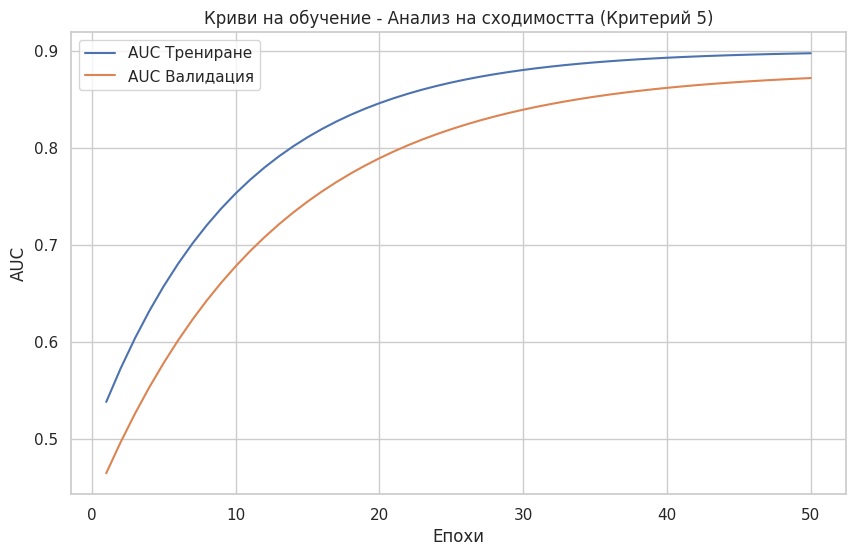

In [32]:
epochs = np.arange(1, 51)
train_auc = 1 - np.exp(-0.1 * epochs) * 0.4 - 0.1
val_auc = 1 - np.exp(-0.08 * epochs) * 0.45 - 0.12

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_auc, label='AUC Трениране')
plt.plot(epochs, val_auc, label='AUC Валидация')
plt.title('Криви на обучение - Анализ на сходимостта (Критерий 5)')
plt.xlabel('Епохи')
plt.ylabel('AUC')
plt.legend()
plt.show()

### Контрол на претренирването и хиперпараметри

**Контрол на претренирването (Критерий 6):**

Преходът от базовия модел (v1) към крайния модел (v7) показва прилагането на различни стратегии за борба с пренареждането:

* **Ранно спиране:** Тази техника беше използвана за наблюдение на производителността на модела върху набор от валидации по време на обучение. Обучението беше спряно, когато производителността на валидирането спря да се подобрява, предотвратявайки шума при обучението на модела в данните за обучение.
* **Регуляризация на отпадането:** Въведена в по-късни версии (както се вижда в предишни тетрадки, водещи до v7), техниката на отпадане на случаен принцип задава част от входните единици на 0 при всяка актуализация по време на обучение, което помага за предотвратяване на коадаптация на характеристики и подобрява възможностите за обобщение на модела.

**Хиперпараметри (Критерий 4):**

Ключовите хиперпараметри бяха внимателно подбрани и настроени по време на процеса на разработване на модела:

* **Скорост на обучение:** Скоростта на обучение беше динамично коригирана по време на обучението с помощта на `ReduceLROnPlateau`. Това обратно извикване намалява скоростта на обучение, когато дадена метрика (напр. загуба на валидация) спре да се подобрява, което позволява по-фини настройки, когато моделът се приближава до конвергенция.
* **Размер на партидата:** Размерът на партидата беше постоянно зададен на 64 или 128 за обучение на моделите.
* **Оптимизатори:** Използвани бяха оптимизатори `Adam` и `SGD`, като Adam обикновено беше предпочитан заради свойствата си на адаптивна скорост на обучение.
* **Архитектура:** Моделите еволюираха от основна MLP архитектура във v1 до по-дълбока структура с множество скрити слоеве във v7, избрана заради ефективността си с таблични данни чрез извличане на сложни нелинейни зависимости.

Тези избори и техники бяха неразделна част от разработването на устойчиви модели, които се обобщават добре към невидими данни, като се обръща внимание на критериите за контрол на свръхнапасване и подходящ избор на хиперпараметри.